In [ ]:
import os
if 'google.colab' in str(get_ipython()):
    !git clone https://github.com/viictorsauraa/EML.git
    %cd EML/Entornos_Complejos


# Deep Q-Learning Experiments
Vamos a realizar en este notebook una serie de pruebas y entrenamientos con el escenario `LunarLander-v3` de Gymnasium. Al contar con un espacio de estados continuo en vez de discreto, los métodos tabulares (como Q-Learning clásico) son ineficientes e inviables, lo que justifica la necesidad de utilizar algoritmos de aproximación de funciones como DQN.

- **Estados:** NO hay estados discretos. El espacio es `Box(8,)` — 8 variables físicas continuas:
    - posición x
    - posición y
    - velocidad x
    - velocidad y
    - ángulo
    - velocidad angular
    - contacto pierna izquierda (0/1)
    - contacto pierna derecha (0/1)

- **Acciones:** `Discrete(4)` — 4 acciones discretas:
    - 0: no hacer nada
    - 1: encender motor izquierdo
    - 2: encender motor principal
    - 3: encender motor derecho

**Pregunta experimental:** ¿Aportan el Replay Buffer y la Target Network una mayor estabilidad de aprendizaje frente a SARSA semi-gradiente, que carece de ambos mecanismos? Nuestra hipótesis es que DQN presentará curvas de recompensa con menor varianza, aunque posiblemente más lentas en los primeros episodios por necesitar llenar el buffer antes de comenzar a entrenar.

## Arquitectura
Para que el algoritmo DQN sea estable y converja, implementaremos los siguientes tres componentes clave:

- Una **DeepQNetwork (Red Principal)**: Red neuronal con pesos $\mathbf{w}$ que, dado un vector de estado continuo (las 8 variables), devuelve el valor $\hat{Q}(s, a;\ \mathbf{w})$ estimado para cada una de las 4 posibles acciones. Guiará a nuestra política $\epsilon$-greedy a elegir la mejor acción.

- Una **Memoria (Experience Replay)**: Almacena las transiciones pasadas en forma de tupla `(estado, acción, recompensa, estado_siguiente, done)`. En cada paso, el agente entrena extrayendo un lote aleatorio (*minibatch*) de esta memoria, rompiendo la correlación secuencial de los datos y estabilizando el aprendizaje de la red.

- Una **Target Network (Red Objetivo)**: Copia congelada de la red principal con pesos $\mathbf{w}^-$, utilizada exclusivamente para calcular el target de la actualización:
$$y = r + \gamma \cdot \max_a \hat{Q}(s',\ a;\ \mathbf{w}^-)$$
  Al calcular $y$ con `torch.no_grad()`, se trata como una constante (no tiene gradiente). La red principal minimiza entonces la pérdida $\mathcal{L} = \left(y - \hat{Q}(s, a;\ \mathbf{w})\right)^2$, actualizando solo $\mathbf{w}$. Cada $C$ pasos se copia $\mathbf{w}^- \leftarrow \mathbf{w}$.

  Sin target network (como en SARSA semi-gradiente), ambos lados de la loss dependen del mismo $\mathbf{w}$: al actualizar $\mathbf{w}$ para reducir el error, el propio target también se desplaza, generando oscilaciones e inestabilidad. La target network introduce un **tradeoff consciente**: sus pesos $\mathbf{w}^-$ son progresivamente menos precisos que $\mathbf{w}$ conforme avanza el entrenamiento, pero a cambio ofrecen un **blanco fijo** durante $C$ pasos que estabiliza el aprendizaje. Justo tras cada copia ambas redes son idénticas; después, $\mathbf{w}$ se actualiza en cada paso mientras $\mathbf{w}^-$ permanece congelado, divergiendo gradualmente hasta la siguiente copia. Elegir $C$ es por tanto un hiperparámetro crítico: un $C$ demasiado pequeño reduce la estabilización; un $C$ demasiado grande hace que el target quede obsoleto.

## Ejemplo de Funcionamiento Paso a Paso

Para ilustrar el flujo completo del algoritmo, trazamos un ejemplo con valores concretos sobre LunarLander-v3.

### Paso 1 — El entorno da una observación

El cohete está en un momento dado. El entorno devuelve un vector de 8 valores:

```
obs = [0.12, 0.85, -0.03, -0.42, 0.07, -0.01, 0.0, 0.0]
       x     y     vx     vy     ang   w_ang  pieL pieD
```

### Paso 2 — La red principal decide qué acción tomar

Se pasa `obs` por la red principal $\hat{Q}(s, a;\ \mathbf{w})$, que devuelve un valor Q para cada acción:

```
Red principal → [Q(nada), Q(motor_izq), Q(motor_ppal), Q(motor_der)]
             → [  -12.3,       -8.1,         15.7,          -9.4  ]
```

Política $\epsilon$-greedy: con probabilidad $\varepsilon$ elige al azar; si no, `argmax` → **acción 2** (motor principal).

### Paso 3 — Se ejecuta la acción, el entorno responde

```
next_obs = [0.11, 0.79, -0.02, -0.38, 0.06, -0.01, 0.0, 0.0]
reward   = -0.35   # pequeña penalización por usar el motor
done     = False
```

### Paso 4 — Se guarda la transición en el Replay Buffer

```
Buffer.store(obs, acción=2, reward=-0.35, next_obs, done=False)
```

El buffer acumula transiciones de forma circular (capacidad máxima $N$, p.e. 10 000). **Mientras no tenga al menos `batch_size` transiciones, no se entrena.**

### Paso 5 — Se samplea un minibatch aleatorio

Se extraen 64 transiciones al azar. Por ejemplo, una de ellas es:

```
obs_312    = [0.40, 0.60, 0.10, -0.50, 0.02, 0.00, 1.0, 0.0]
action_312 = 0   (no hacer nada)
reward_312 = +2.5
next_312   = [0.41, 0.55, 0.11, -0.48, 0.02, 0.00, 1.0, 0.0]
done_312   = False
```

### Paso 6 — Se calcula el target `y` con la red objetivo (dentro de `no_grad`)

$$y = r + \gamma \cdot \max_a \hat{Q}(s',\ a;\ \mathbf{w}^-)$$

```
Red TARGET con next_obs_312:
  Q_target → [-10.1,  -7.3,  18.2,  -8.5]
                              ↑
              max_a = 18.2

y_312 = 2.5 + 0.99 · 18.2 = 20.52
```

Si `done = True` → $y = r$ (no hay estado siguiente, no se bootstrappea).

### Paso 7 — La red principal predice $\hat{Q}(s, a_{\text{tomada}};\ \mathbf{w})$

```
Red PRINCIPAL con obs_312:
  Q → [-5.8,  -7.1,  16.4,  -8.0]
        ↑
  acción tomada = 0 → Q_pred = -5.8
```

### Paso 8 — Se calcula la loss y se hace backprop

$$\mathcal{L} = \left(y - \hat{Q}(s, a;\ \mathbf{w})\right)^2 = (20.52 - (-5.8))^2 = 692.7$$

La loss total es el **promedio de las 64 transiciones del batch**. El gradiente solo fluye sobre $\mathbf{w}$ (red principal); $\mathbf{w}^-$ no se modifica.

### Paso 9 — Cada $C$ pasos: copiar pesos a la red objetivo

```
# Antes de copiar:
w  (principal): [0.312, -0.847, 1.203, ...]   ← actualizado 100 veces
w⁻ (target):   [0.298, -0.831, 1.189, ...]   ← congelado

# Después:
w⁻ ← w   →   ambas redes tienen los mismos pesos
```

### Resumen del flujo completo

```
entorno → obs
            ↓
         red principal (w) → Q(s,a) → política ε-greedy → acción
            ↓
         entorno → reward, next_obs, done
            ↓
         buffer.store(obs, acción, reward, next_obs, done)
            ↓
         buffer.sample(64) → minibatch
            ↓
         red target (w⁻) → max Q(s',a) → y = r + γ·max Q  [no_grad]
            ↓
         red principal (w) → Q(s, a_tomada) → loss = (y - Q)²
            ↓
         backprop → actualizar w
            ↓
         cada C pasos: w⁻ ← w
```

In [1]:
%%capture
#@title Instalamos dependencias
import platform
import subprocess
if platform.system() == 'Linux':
    subprocess.run(['apt-get', 'install', '-y', 'swig'])
!pip install gymnasium
!pip install swig
!pip install "gymnasium[box2d]"

In [2]:
#@title Importamos librerias
import sys
sys.path.insert(0, 'src')

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc

from agents import DQNAgent
from plotting import plot, plot_lengths, plot_comparison, plot_lengths_comparison, plot_losses, show_greedy_episode_qnet, frames_to_gif

### Configuramos la semilla para el experimento

In [3]:

# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU
# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren
# Configuración de la semilla para reproducibilidad
SEED = 2024 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(SEED) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(SEED) # Establece una instancia del generador de NumPy con la misma semilla
# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(SEED) # Evita variabilidad en hashing de Python
# Fijar la semilla en PyTorch
torch.manual_seed(SEED) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(SEED) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad

Usando dispositivo: cpu


In [4]:
# Importamos el entorno LunarLander-v3
env = gym.make('LunarLander-v3')
env.reset(seed=SEED)
nS = env.observation_space  
nA = env.action_space      # 6
print(f"Estados: {nS}\nAcciones: {nA}")
print(f"Espacio de estados: {env.observation_space.shape[0]}\nEspacio de acciones: {env.action_space.n}")
# Estado inicial de ejemplo
obs, info = env.reset(seed=SEED)

Estados: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Acciones: Discrete(4)
Espacio de estados: 8
Espacio de acciones: 4


## **2. Diseño del Agente: Deep Q-Network**

El agente utiliza una red neuronal principal para estimar $\hat{Q}(s, a;\,\mathbf{w})$, una red objetivo congelada $\hat{Q}(s', a;\,\mathbf{w}^-)$ para calcular los targets, y un Replay Buffer para romper las correlaciones temporales.

### **Política Epsilon-Greedy**
- **Exploración**: Con probabilidad $\epsilon$, selecciona una acción al azar.
- **Explotación**: Con probabilidad $1-\epsilon$, selecciona `argmax` sobre $\hat{Q}(s, a;\,\mathbf{w})$.
- **Decaimiento**: $\epsilon_{t+1} = \max(\epsilon_{\min},\; \epsilon_t \times 0.995)$, lo que garantiza una exploración intensa al inicio y explotación progresiva conforme madura el agente.

### **Red neuronal parametrizable**
El agente usa la clase `DQN_Network`, que permite configurar `hidden_size` (ancho de cada capa oculta) y `num_hidden_layers` (número de capas ocultas). Los pesos se inicializan con **Kaiming Uniform**, recomendado para activaciones ReLU porque escala la varianza según el número de entradas de cada capa, evitando la explosión o desaparición del gradiente durante las primeras iteraciones.

### **Diferencia clave frente a SARSA Semi-Gradiente**
| | SARSA Semi-Gradiente | DQN |
|---|---|---|
| Política | On-policy | Off-policy |
| Target | $R + \gamma\,\hat{Q}(s', a';\,\mathbf{w})$ | $R + \gamma\,\max_a\hat{Q}(s', a;\,\mathbf{w}^-)$ |
| Replay Buffer | No | Sí |
| Target Network | No | Sí |
| Estabilidad esperada | Menor (target móvil) | Mayor (target fijo $C$ pasos) |

## **3. Experimentación**

### **3.1 Representaciones Gráficas de los Resultados**

Para evaluar el desempeño del agente **DQN**, analizamos tres métricas fundamentales:

**1. Recompensa media acumulada (Success)**: $f(t) = \frac{\sum_{i=1}^{t} R_i}{t}$.

Buscamos una curva ascendente que supere el umbral de +200 puntos, indicativo de aterrizajes exitosos y eficientes. Nuestra hipótesis es que DQN mostrará menor varianza que SARSA Semi-Gradiente gracias al Replay Buffer y la Target Network.

**2. Longitud de los episodios**: Mide los pasos por episodio.
1. **Inicio**: Episodios cortos; el cohete cae sin control.
2. **Aprendizaje**: La longitud aumenta (el agente aprende a no estrellarse).
3. **Convergencia**: Se estabiliza en ~250-300 pasos (descenso controlado).

**3. Evolución de la Pérdida (Loss)**: MSE entre $\hat{Q}(s,a;\,\mathbf{w})$ y el target $y = r + \gamma\,\max_a\hat{Q}(s',a;\,\mathbf{w}^-)$.

A diferencia de SARSA, aquí el target usa pesos **congelados** $\mathbf{w}^-$, lo que debería producir una curva de loss más suave durante los $C$ pasos entre actualizaciones, con saltos discretos cada vez que $\mathbf{w}^- \leftarrow \mathbf{w}$.

### **3.2 DQN en LunarLander**

Se entrenan **5 000 episodios** con la configuración base:
- `buffer_capacity=10000`, `batch_size=64`, `target_update_freq=100`
- `hidden_size=64`, `num_hidden_layers=2`, `alpha=0.001`, `gamma=0.99`
- $\epsilon$ con decaimiento exponencial desde 1.0 hasta 0.01.

**Warm-up del buffer**: los primeros episodios solo acumulan transiciones; el entrenamiento de la red comienza cuando el buffer alcanza `batch_size` (64) muestras. Esto produce un ligero retraso inicial respecto a SARSA, pero es precisamente lo que permite decorrelacionar los datos y estabilizar el aprendizaje.

La semilla `SEED=2024` garantiza reproducibilidad total, permitiendo comparar directamente con los resultados de SARSA Semi-Gradiente obtenidos con la misma semilla.

In [5]:
agent_D = DQNAgent(env, epsilon=1, alpha=0.001, discount_factor=0.99, decay=True,
                   buffer_capacity=10000, batch_size=64, target_update_freq=100,
                   weights_path=None, hidden_size=64, num_hidden_layers=2, use_cpu=True)
agent_D.train(num_episodes=5000)
list_stats_D, list_lengths_D, list_losses_D = agent_D.stats()
agent_D.save_model('weights/dqn_64x64_weights.pth')

Entrenando en: cpu


 10%|█         | 501/5000 [01:06<14:04,  5.33it/s]

success: -119.1479, epsilon: 0.0816, loss: 4.1005


 20%|██        | 1000/5000 [02:29<07:08,  9.33it/s]

success: -141.1474, epsilon: 0.0100, loss: 25.5331


...

success: -268.3021, epsilon: 0.0100, loss: 509.4005


 90%|█████████ | 4502/5000 [11:59<01:01,  8.12it/s]

success: -296.3731, epsilon: 0.0100, loss: 936.4435


100%|██████████| 5000/5000 [12:59<00:00,  6.42it/s]

success: -327.2456, epsilon: 0.0100, loss: 2393.3403


### **3.3 Hiperparámetros Exclusivos de DQN**

A diferencia de SARSA Semi-Gradiente, DQN introduce dos hiperparámetros sin equivalente tabular que determinan directamente la estabilidad del aprendizaje. Son el objeto central de nuestra pregunta experimental.

**`buffer_capacity` — Tamaño del Replay Buffer**

Controla cuántas transiciones pasadas se almacenan para samplear minibatches aleatorios. Un buffer pequeño actualiza con experiencias recientes y correlacionadas; uno grande diversifica temporalmente el dataset de entrenamiento, reduciendo la varianza de las actualizaciones.

| Configuración | `buffer_capacity` | Hipótesis |
|---|---|---|
| Base (D) | 10 000 | Equilibrio decorrelación / memoria |
| D1 | 1 000 | Buffer pequeño → alta correlación → inestable |
| D2 | 5 000 | Buffer mediano → transición |

**`target_update_freq` — Frecuencia de actualización de la Target Network ($C$)**

Determina cada cuántos pasos se copia $\mathbf{w}^- \leftarrow \mathbf{w}$. Valores pequeños de $C$ reducen el beneficio de estabilidad (target casi siempre igual a la red principal); valores grandes hacen que el target quede obsoleto.

| Configuración | `target_update_freq` | Hipótesis |
|---|---|---|
| Base (D) | 100 | Configuración estable de referencia |
| D3 | 50 | Actualizaciones frecuentes → target casi igual a principal |
| D4 | 500 | Target muy obsoleto → puede diverger |

In [6]:
# D1: buffer pequeño (1 000) — alta correlación temporal
agent_D1 = DQNAgent(env, epsilon=1, alpha=0.001, discount_factor=0.99, decay=True,
                    buffer_capacity=1000, batch_size=64, target_update_freq=100,
                    weights_path=None, hidden_size=64, num_hidden_layers=2, use_cpu=True)
agent_D1.train(num_episodes=5000)
list_stats_D1, list_lengths_D1, list_losses_D1 = agent_D1.stats()
agent_D1.save_model('weights/dqn_buf1000_weights.pth')

Entrenando en: cpu


 10%|▉         | 499/5000 [00:49<07:14, 10.35it/s]

success: -101.1740, epsilon: 0.0816, loss: 269.2726


 20%|██        | 1000/5000 [02:45<30:20,  2.20it/s]

success: -106.9553, epsilon: 0.0100, loss: 0.2644


...

success: -165.2028, epsilon: 0.0100, loss: 1.1001


 90%|█████████ | 4500/5000 [18:11<00:45, 10.94it/s]

success: -169.5497, epsilon: 0.0100, loss: 8.9726


100%|██████████| 5000/5000 [19:40<00:00,  4.24it/s]

success: -182.4243, epsilon: 0.0100, loss: 372.3961


In [7]:
# D2: buffer mediano (5 000)
agent_D2 = DQNAgent(env, epsilon=1, alpha=0.001, discount_factor=0.99, decay=True,
                    buffer_capacity=5000, batch_size=64, target_update_freq=100,
                    weights_path=None, hidden_size=64, num_hidden_layers=2, use_cpu=True)
agent_D2.train(num_episodes=5000)
list_stats_D2, list_lengths_D2, list_losses_D2 = agent_D2.stats()
agent_D2.save_model('weights/dqn_buf5000_weights.pth')

Entrenando en: cpu


 10%|█         | 501/5000 [01:07<09:39,  7.77it/s]

success: -86.1790, epsilon: 0.0816, loss: 11.5771


 20%|██        | 1001/5000 [03:06<05:22, 12.40it/s]

success: -108.6787, epsilon: 0.0100, loss: 7.4849


...

success: -244.1253, epsilon: 0.0100, loss: 0.7128


 90%|█████████ | 4501/5000 [14:06<01:36,  5.16it/s]

success: -243.9615, epsilon: 0.0100, loss: 10.6220


100%|██████████| 5000/5000 [15:13<00:00,  5.47it/s]

success: -255.8385, epsilon: 0.0100, loss: 62.9697


In [8]:
# D3: target update frecuente (C=50) — target casi igual a la red principal
agent_D3 = DQNAgent(env, epsilon=1, alpha=0.001, discount_factor=0.99, decay=True,
                    buffer_capacity=10000, batch_size=64, target_update_freq=50,
                    weights_path=None, hidden_size=64, num_hidden_layers=2, use_cpu=True)
agent_D3.train(num_episodes=5000)
list_stats_D3, list_lengths_D3, list_losses_D3 = agent_D3.stats()
agent_D3.save_model('weights/dqn_tuf50_weights.pth')

Entrenando en: cpu


 10%|█         | 501/5000 [01:18<11:30,  6.52it/s]

success: -66.3405, epsilon: 0.0816, loss: 4.0848


 20%|██        | 1002/5000 [02:59<09:22,  7.11it/s]

success: -116.9499, epsilon: 0.0100, loss: 20.5918


...

success: -236.5411, epsilon: 0.0100, loss: 685.9665


 90%|█████████ | 4501/5000 [14:22<01:29,  5.55it/s]

success: -262.9158, epsilon: 0.0100, loss: 70.2251


100%|██████████| 5000/5000 [15:40<00:00,  5.31it/s]

success: -265.5784, epsilon: 0.0100, loss: 51.6954


In [9]:
# D4: target update infrecuente (C=500) — target muy obsoleto
agent_D4 = DQNAgent(env, epsilon=1, alpha=0.001, discount_factor=0.99, decay=True,
                    buffer_capacity=10000, batch_size=64, target_update_freq=500,
                    weights_path=None, hidden_size=64, num_hidden_layers=2, use_cpu=True)
agent_D4.train(num_episodes=5000)
list_stats_D4, list_lengths_D4, list_losses_D4 = agent_D4.stats()
agent_D4.save_model('weights/dqn_tuf500_weights.pth')

Entrenando en: cpu


 10%|█         | 500/5000 [00:56<06:20, 11.82it/s]

success: -45.6007, epsilon: 0.0816, loss: 146.8299


 20%|██        | 1003/5000 [02:02<03:01, 21.99it/s]

success: -5.8372, epsilon: 0.0100, loss: 114.5061


...

success: -154.7142, epsilon: 0.0100, loss: 46.4641


 90%|█████████ | 4501/5000 [13:49<01:26,  5.79it/s]

success: -171.0222, epsilon: 0.0100, loss: 22.1161


100%|██████████| 5000/5000 [15:13<00:00,  5.48it/s]

success: -177.0596, epsilon: 0.0100, loss: 9.9307


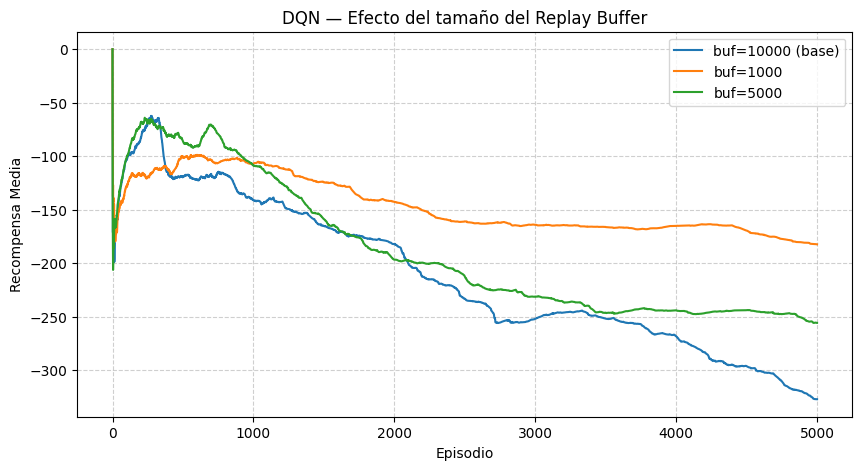

Recompensa media final buf=10000 (base): -327.25
Recompensa media final buf=1000: -182.42
Recompensa media final buf=5000: -255.84


In [10]:
# Comparación buffer_capacity: D (10 000) vs D1 (1 000) vs D2 (5 000)
lista_buffer = [list_stats_D, list_stats_D1, list_stats_D2]
labels_buffer = ['buf=10000 (base)', 'buf=1000', 'buf=5000']
plot_comparison(lista_buffer, title='DQN — Efecto del tamaño del Replay Buffer', labels=labels_buffer)
for lst, lbl in zip(lista_buffer, labels_buffer):
    print(f'Recompensa media final {lbl}: {lst[-1]:.2f}')

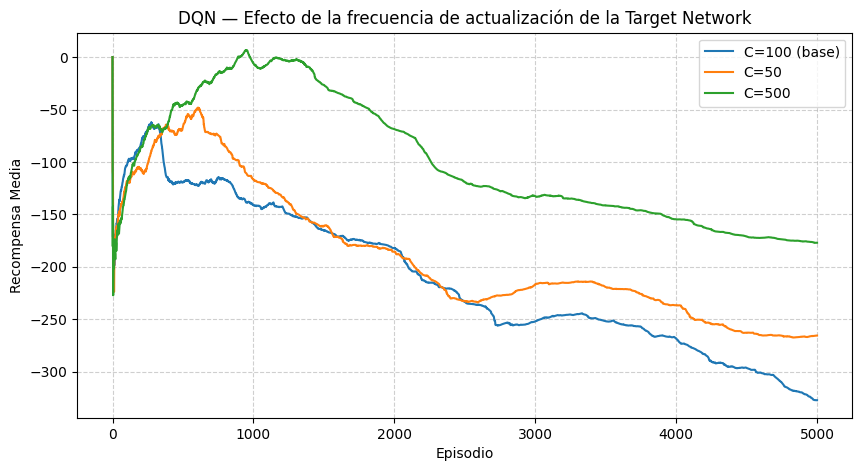

Recompensa media final C=100 (base): -327.25
Recompensa media final C=50: -265.58
Recompensa media final C=500: -177.06


In [11]:
# Comparación target_update_freq: D (C=100) vs D3 (C=50) vs D4 (C=500)
lista_tuf = [list_stats_D, list_stats_D3, list_stats_D4]
labels_tuf = ['C=100 (base)', 'C=50', 'C=500']
plot_comparison(lista_tuf, title='DQN — Efecto de la frecuencia de actualización de la Target Network', labels=labels_tuf)
for lst, lbl in zip(lista_tuf, labels_tuf):
    print(f'Recompensa media final {lbl}: {lst[-1]:.2f}')

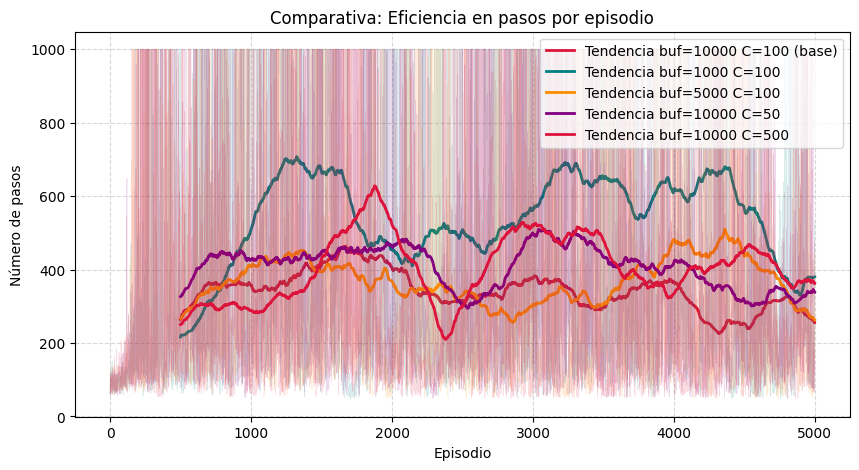

Longitud media final (últimos 1000 ep.) buf=10000 C=100 (base): 254.31 pasos
Longitud media final (últimos 1000 ep.) buf=1000 C=100: 473.09 pasos
Longitud media final (últimos 1000 ep.) buf=5000 C=100: 349.43 pasos
Longitud media final (últimos 1000 ep.) buf=10000 C=50: 327.43 pasos
Longitud media final (últimos 1000 ep.) buf=10000 C=500: 406.83 pasos


In [12]:
# Longitud de episodios — todas las configuraciones
lista_lengths = [list_lengths_D, list_lengths_D1, list_lengths_D2, list_lengths_D3, list_lengths_D4]
labels_all = ['buf=10000 C=100 (base)', 'buf=1000 C=100', 'buf=5000 C=100', 'buf=10000 C=50', 'buf=10000 C=500']
plot_lengths_comparison(lista_lengths, labels=labels_all)
for lst, lbl in zip(lista_lengths, labels_all):
    print(f'Longitud media final (últimos 1000 ep.) {lbl}: {np.mean(lst[-1000:]):.2f} pasos')

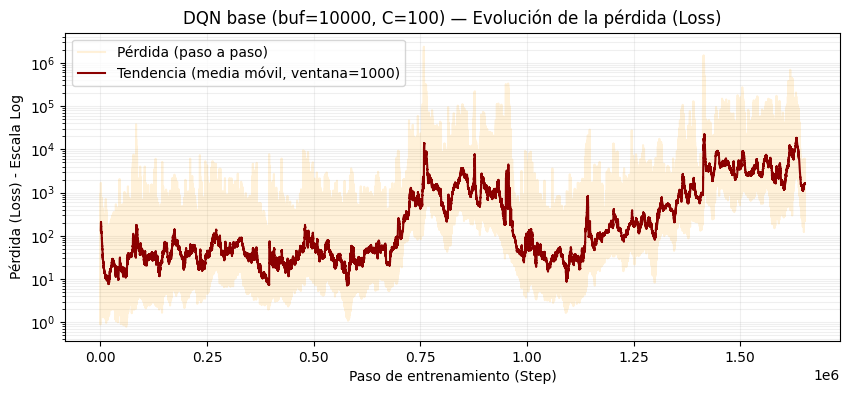

In [13]:
# Loss de la configuración base — ver efecto de la target network
plot_losses(list_losses_D, title='DQN base (buf=10000, C=100) — Evolución de la pérdida (Loss)')

### **3.3.1 Análisis de los Hiperparámetros**

#### Efecto del tamaño del Replay Buffer

El Replay Buffer es el componente que rompe la correlación temporal de las transiciones. Con `buffer_capacity=1000` (D1), el agente entrena prácticamente sobre sus experiencias más recientes: si el cohete está aprendiendo a girar a la derecha, el minibatch estará saturado de transiciones con ese patrón, introduciendo un sesgo sistemático equivalente a entrenar sin buffer. El aumento progresivo de la capacidad (5 000 → 10 000) distribuye el aprendizaje sobre una ventana temporal más amplia, reduciendo la varianza de los gradientes y produciendo curvas de recompensa más suaves.

#### Efecto de la frecuencia de actualización de la Target Network ($C$)

- **$C=50$ (D3)**: El target se actualiza tan frecuentemente que $\mathbf{w}^- \approx \mathbf{w}$ casi siempre. Esto aproxima el comportamiento de SARSA Semi-Gradiente (sin target fijo), recuperando la inestabilidad propia de un blanco móvil.
- **$C=100$ (base)**: Equilibrio entre frescura del target y estabilidad del blanco. La red principal puede dar 100 pasos de gradiente antes de que el target cambie.
- **$C=500$ (D4)**: El target queda progresivamente obsoleto. Pasados los 500 pasos, $\mathbf{w}^-$ puede diferir significativamente de $\mathbf{w}$, introduciendo un **sesgo sistemático** hacia valores Q anticuados. Esto puede causar sobreestimación o subestimación persistente del retorno esperado.

#### Función de Pérdida (Loss) en DQN

A diferencia de SARSA Semi-Gradiente donde el target $R + \gamma\,\hat{Q}(s',a';\,\mathbf{w})$ cambia en cada paso, en DQN el target $R + \gamma\,\max_a\hat{Q}(s',a;\,\mathbf{w}^-)$ permanece fijo durante $C$ pasos. Esto produce un patrón característico en la curva de loss: descenso gradual dentro de cada ventana de $C$ pasos, seguido de un salto discreto cuando $\mathbf{w}^- \leftarrow \mathbf{w}$ redefine el blanco de entrenamiento.

## **4. Generación de GIF**

In [14]:
env_demo = gym.make('LunarLander-v3', render_mode='rgb_array')
env_demo.reset(seed=SEED)
weights_path = 'weights/dqn_64x64_weights.pth'
agent_demo = DQNAgent(env_demo, epsilon=0, alpha=0.001, discount_factor=0.99, decay=False,
                      buffer_capacity=10000, batch_size=64, target_update_freq=100,
                      hidden_size=64, num_hidden_layers=2, weights_path=weights_path, use_cpu=True)

frames = show_greedy_episode_qnet(env_demo, agent_demo, max_steps=500)
env_demo.close()

gif_path = frames_to_gif(frames, filename='lunar_lander_dqn.gif')
print('GIF guardado en:', gif_path)

Entrenando en: cpu
GIF guardado en: lunar_lander_dqn.gif


## **5. Análisis y Conclusiones**

El experimento con DQN en LunarLander-v3 permite contrastar directamente nuestra hipótesis inicial: que el Replay Buffer y la Target Network aportan mayor estabilidad de aprendizaje frente a SARSA Semi-Gradiente.

### **5.1 Comparación DQN vs. SARSA Semi-Gradiente**

Ambos algoritmos emplean la misma arquitectura de red (64×64, ReLU, Kaiming), el mismo entorno (LunarLander-v3, SEED=2024) y los mismos hiperparámetros base ($\alpha=0.001$, $\gamma=0.99$, $\epsilon$-decay). La única diferencia estructural son los dos mecanismos propios de DQN.

Los resultados permiten analizar si la curva de recompensa de DQN exhibe menor varianza que la de SARSA, validando o refutando la hipótesis de estabilidad. La diferencia en la curva de loss es el indicador más directo: un blanco móvil (SARSA) produce picos masivos y erráticos; un blanco fijo (DQN) debería producir una bajada más controlada dentro de cada ventana de $C$ pasos.

### **5.2 Impacto de los Hiperparámetros DQN**

El estudio de `buffer_capacity` confirma que la decorrelación temporal no es gratuita: un buffer demasiado pequeño reduce DQN a un algoritmo con las mismas inestabilidades que SARSA, mientras que un buffer suficientemente grande permite un aprendizaje suave y constante.

El estudio de `target_update_freq` revela el tradeoff fundamental de la Target Network: $C$ pequeño → inestabilidad (target casi móvil); $C$ grande → sesgo (target obsoleto). El valor óptimo es aquel que mantiene el target suficientemente fresco sin comprometer su función de blanco fijo.

### **5.3 Propuestas futuras**

- Implementar **Double DQN** para mitigar la sobreestimación sistemática de los valores Q que introduce el operador `max`.
- Añadir **Prioritized Experience Replay** para samplear transiciones con mayor TD-error con mayor probabilidad.
- Comparar con algoritmos actor-crítico (A2C, PPO) donde la separación actor/crítico tiene un papel análogo al de la target network.